## Recluster using CRP instead of ESR, and compare the differences in JIP-assignment

We do this in another dataset: BeSt (where we have both ESR & CRP)

In [5]:
import pandas as pd

file_path = '/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/10 jaars basisbestand clean.dta'

# Read the Stata file into a pandas DataFrame
df_demographics_old = pd.read_stata(file_path)

d_map = {
    'patnr' : 'PATNR',
    # Demographics
    'age' : 'Age',
    'gender' : 'Sex',
    
    # Serology
    'CCP2' : 'aCCP',
    'RF' : 'RF'
    
}

df_demographics_old = df_demographics_old.rename(columns= d_map)

# Add another table (which features symptom duration among other variables)
file_path = '/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/Baseline variabelen.dta'

# Read the Stata file into a pandas DataFrame
df_demographics = pd.read_stata(file_path)
df_demographics = df_demographics.rename(columns= {'kladuurw' : 'symptomDuration', 'patnr' : 'PATNR'})


# Get the unique columns
columns_to_add = list(set(df_demographics_old.columns) - set(df_demographics.columns))
columns_to_add.append('PATNR')

# We merge on PATNR to add both demographic tables together into one powerful table
df_demographics = pd.merge(df_demographics, df_demographics_old[columns_to_add], left_on='PATNR', right_on='PATNR')

df_demo = df_demographics[['PATNR', 'Age','Sex', 'aCCP', 'RF']].copy()


In [ ]:
import pandas as pd

# Replace 'your_file.dta' with the actual file path
file_path = '/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/Visites_Monitoringdatabase_baseline.csv'

# Read the Stata file into a pandas DataFrame
df_lab = pd.read_csv(file_path, sep=';')

# Select baseline only
df_lab = df_lab[df_lab['Visite nummer']==1] # Select baseline only 

# Rename certain columns 
df_lab =df_lab.rename(columns = {'Patientnummer Best' : 'PATNR', 'Datum visit' : 'FirstConsult'})

d_map = {
    
    
    # Inflammatory markers
    'CRP' : 'CRP',
    'BSE (1e uur)' : 'BSE',
    
    # Hematological workup
    'Hemoglobine' : 'Hb', # Or LABHB2
    'Hematocriet' : 'Ht',
    'MCV' : 'MCV',
    'Thrombocyten' : 'Trom',
    'Lymfocyten' : 'Lym',
    'Leucocyten' : 'Leuko',
    "Physician's global assesment of disease activity" : 'EGA', # EGA 
    "Ziekte-activiteit (VAS)" : 'PGA',
    
    'labNeutnd' : 'Neutro'
    
    # MCHC?
    # MCH?
    
    # 'Temperatuur',
    # 'Lengte',
    # 'Gewicht',
}

df_lab = df_lab.rename(columns= d_map)

df_lab['CRP'] = df_lab['CRP'].apply(lambda x : x.replace(',', '.').replace('<', '') if x == x else x)
df_lab['CRP'] = df_lab['CRP'].astype(float)
df_lab = df_lab.dropna(subset=['CRP'])
df_lab

### preprocess data

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler # Z-score
from sklearn.preprocessing import RobustScaler  # Robust Z-score
from sklearn.preprocessing import PowerTransformer # Yeo-Johnson
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd

def BinarizeSerology(val, include_na=True):
    """
    Standardize the categorical variables to numerical values
    
    where:
        0 = Negative
        1 = Positive
        2 = Missing
    
    Input:
        val = Categorical value 
        include_na = whether or to include missing values
            - in case the missingness contains information
            - you should keep these values!
    Output:
        val = codified categorical value
    """
    
    if val in ['Positief', 'Sterk pos.', 'Sterk pos', 'Sterk Positief']:
        val = 1
    elif val in ['Dubieus', 'Negatief', 'Zwak pos.', 'Zwak pos', 'Zwak Positief']:
        val= 0
    elif include_na:
        if val in ['Onbekend', 'Stopgezet', '-volgt-', '@volgt', 'Niet doorgeg', 'Niet het jui', 
                   'gestopt', 'Bepaling niet ui', ' ', 'Geen analyse mog', 'Te weinig materi', 
                   'Geen materiaal o', 'te weinig ma', 'gestopt',  'Geen analyse', 'geen uitslag', np.nan]:
            val = np.nan
    return val

def normalizeLab(df):
    """
    Input: 
        df = complete dataframe
    
    Description:
        This function processes the Lab data. 
        Categorical data is subjected to a one-hot-encoding
        while the numerical data is cast to a z-scale as normalization
        
        Furthermore, the ESR (or BSE in dutch) is subjected to a 
        log-transformation.
    
    Output:
        df_dummies = dataframe with preprocessed categorical data 
        df_b = dataframe with preprocessed numerical data
    """
    l_num = ['Leuko', 'Hb', 'MCV', 'Trom', 'BSE', 'Age'] # 'Ht', 
    
    # Log transform the ESR data
    df['BSE'] = np.log(df['BSE'])
    
    ct = ColumnTransformer([("num", PowerTransformer(), l_num)], remainder="passthrough")
    df_num= pd.DataFrame(ct.fit_transform(df[l_num]), columns=l_num)
    return df_num.merge(df['PATNR'], left_index=True, right_index=True)

l_num = ['PATNR', 'Leuko', 'Hb', 'MCV', 'Trom',  'BSE', 'Age'] # 'Ht', 

# Define df lab
df_lab= df_num[l_num].copy()

# Save lab data (unnormalized)
#df_lab.to_csv(r'/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/BeSt_Lab_wide_unscaled_withCRP.csv', sep='|', index=False)
#print('Written to ../new_data/offshoots/ERC_SyG/BeSt_Lab_wide_unscaled.csv')

# Normalize lab values
df_lab_sc = normalizeLab(df_lab.copy())

# Save lab data (normalized)
df_lab_sc.to_csv(r'/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/BeSt_Lab_wide_scaled_withCRP.csv', sep='|', index=False)
df_lab_sc.head()

print(len(df_lab_sc), len(df_lab_sc['PATNR'].unique()))

494 494


### Create new metadata (only featuring 494 pat with CRP instead of ESR)

In [60]:
# only select patients in metadata with CRP status

l_pat_repl = list(df_lab_sc['PATNR'].unique())
df_meta = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/metadata_best.csv', sep='|')
df_meta[df_meta['PATNR'].isin(l_pat_repl)].to_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/metadata_best_withCRP.csv', sep='|', index=False)

## #2. Project new data

Load different custom env: 
conda activate /exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/

### #2.1 Force same dimensions
We have less caterogical features in the replication set, thus we are required to reduce the dimensions. In order to create a shared latent space in the next step

In [4]:
import pandas as pd

l_num = ['Leuko', 'Hb', 'MCV', 'Trom', 'BSE', 'Age'] # 'Ht', 
#l_num = ['Leuko', 'Ht', 'Hb', 'MCV', 'Trom', 'BSE', 'Age', 'PATNR']

l_cat_shared = list(pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/best_columns_cat.csv', sep='|')['Columns'].values)
l_cat_patnr =  l_cat_shared[:-1]
l_cat_patnr.append('PATNR')

# Variables from development set
df_numeric = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_lab_scaled_demographics.csv', sep=',')
df_numeric['PATNR'] = df_numeric['pseudoId']
df_numeric = df_numeric[l_num].copy()
df_categoric= pd.read_csv('../../new_data/5_clustering/df_categoric_wAge.csv', sep=',')[l_cat_shared]
df_categoric['PATNR'] = df_categoric['pseudoId']

l_num.append('PATNR')

# Variables from replication set
df_categoric_replication = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/df_best_categoric_ohe.csv', sep='|')[l_cat_patnr]
df_numeric_replication = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/BeSt_Lab_wide_scaled_withCRP.csv', sep='|')[l_num]


# Select complete patients
l_essential = ['SJC', 'Leuko', 'Hb', 'MCV', 'Trom',  'BSE', 'RF', 'aCCP', 'Age', 'Sex', 'PATNR'] #  'Ht',
df_meta = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/metadata_best_withCRP.csv', sep='|')
l_pat_repl = list(df_meta[l_essential].dropna()['PATNR'].unique())


df_categoric_replication = df_categoric_replication[df_categoric_replication['PATNR'].isin(l_pat_repl)].copy()
df_numeric_replication = df_numeric_replication[df_numeric_replication['PATNR'].isin(l_pat_repl)].copy()

df_categoric_replication = df_categoric_replication.fillna(0)
df_numeric_replication = df_numeric_replication.fillna(0)

### Create metadata

In [5]:
df_numeric_raw = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/BeSt_Lab_wide_unscaled.csv', sep='|')[l_num]

df_meta = pd.merge(df_categoric_replication, df_numeric_raw, left_on='PATNR', right_on='PATNR')
df_meta['pseudoId'] = df_meta['PATNR'] 

#To Do: add demographics / BeST variables! 
#df_meta.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/BeSt_metadata.csv', sep='|', index=None)

### create combined metadata

In [6]:
# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0
metadata_RA['PATNR'] = metadata_RA['pseudoId'].str[:-2] 

df_meta['Replication'] = 1
df_meta['pseudoId'] = df_meta['PATNR'].copy()

df_meta_full = pd.concat([df_meta, metadata_RA])
df_meta_full.reset_index(drop=True)
df_meta_full.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/Metadata_complete_withCRP.csv', sep='|', index=False)

### #2.2 learn shared product space

In [7]:
import os, platform, subprocess, re

def get_processor_name():
    if platform.system() == "Windows":
        return platform.processor()
    elif platform.system() == "Darwin":
        os.environ['PATH'] = os.environ['PATH'] + os.pathsep + '/usr/sbin'
        command ="sysctl -n machdep.cpu.brand_string"
        return subprocess.check_output(command).strip()
    elif platform.system() == "Linux":
        command = "cat /proc/cpuinfo"
        all_info = subprocess.check_output(command, shell=True).decode().strip()
        for line in all_info.split("\n"):
            if "model name" in line:
                return re.sub( ".*model name.*:", "", line,1)
    return ""

get_processor_name()

' Intel(R) Xeon(R) CPU E5-4657L v2 @ 2.40GHz'

In [ ]:
import time
import numpy as np
import tensorflow as tf
from mmae.multimodal_autoencoder import MultimodalAutoencoder # MMAE



# Be aware: Remove features with zero variation!!


# Use pseudo labels

# Build the model on Original set

input_shapes = {'Categoric': df_categoric[l_cat_patnr[:-1]].shape[1:], 'Numeric': df_numeric.shape[1:]} 
data = [np.array(df_categoric[l_cat_patnr[:-1]].values), np.array(df_numeric.values)]

# Number of units of each layer of encoder network
hidden_dims = [128, 64, 8] # 16?
# Output activation functions for each modality
output_activations = ['sigmoid' , 'relu'] # , 'relu'
# Name of Keras optimizer
optimizer = 'adam'
# Loss functions corresponding to a noise model for each modality
loss = ['bernoulli_divergence', 'gaussian_divergence']

# Set seed
#tf.keras.utils.set_random_seed(1234)
tf.random.set_seed(1234567)

# Construct autoencoder network
autoencoder = MultimodalAutoencoder(input_shapes, hidden_dims,
                                    output_activations)
autoencoder.compile(optimizer, loss)


t0 = time.time()
# Train model where input and output are the same
history = autoencoder.fit(data, epochs=100) # was 100
# maybe 200

t1 = time.time()
print('Time to create product space: ' + str(t1-t0))


# Get Latent space of original data
z_filtered = autoencoder.encode(data)
 
#tf.keras.models.save_model()
# Save maui model state (that only uses variables also present in replication set)
#maui_model.save('/exports/reum/tdmaarseveen/RA_Clustering/models/replication_maui')
autoencoder.save('/exports/reum/tdmaarseveen/RA_Clustering/models/BeSt_MMAE_withCRP')

# Save shared productspace (that only uses variables also present in replication set)
l_embedding = ['PATNR']

df_z = pd.DataFrame(z_filtered)
for ix, col in enumerate(df_z): # z-filtered might be row based
    df_z['LF%s' % ix] = df_z[ix].copy()
    l_embedding.append('LF%s' % ix)
 
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0)
df_z.insert(0, 'PATNR', metadata_RA['pseudoId'])
df_z = df_z[l_embedding].copy()
   
df_z[l_embedding].to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/BeSt_embedding_withCRP.csv', index=False, sep=',')


### #2.2 Project novel instances onto latent embedding


In [9]:
import sys
import pandas as pd
import numpy as np
#from mmae.multimodal_autoencoder import MultimodalAutoencoder # MMAE
import tensorflow as tf
#sys.path.append(r'../../modules/parametric_tsne/')
#sys.path.append(r'../../modules/')
sys.path.append(r'../../src/1_emr_scripts')
import Visualization as func
from sklearn.manifold import TSNE

# --------------------------------- Add new patients ---------------------------------------------
model=tf.keras.models.load_model('/exports/reum/tdmaarseveen/RA_Clustering/models/BeSt_MMAE', compile=False) #_withCRP

df_z = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/BeSt_embedding_withCRP.csv', sep=',')


# Project new sample in product space

metadata_rep = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/metadata_best_withCRP.csv', sep='|')
df_categoric_replication  = df_categoric_replication.fillna(0)
#z_patient = maui_model.transform({ 'Categorical': df_categoric_replication.T, 'Lab_numerical': df_numeric_replication.T})
lcat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]
lnum = [col for col in df_numeric_replication.columns if col not in ['PATNR']]
data = [np.array(df_categoric_replication[lcat].values), np.array(df_numeric_replication[lnum].values)]

z_patient = model.encoder.predict(data, batch_size=256)
z_patient = pd.DataFrame(z_patient)

l_embedding = ['PATNR']
for ix, col in enumerate(z_patient): # z-filtered might be row based
    z_patient['LF%s' % ix] = z_patient[ix].copy()
    l_embedding.append('LF%s' % ix)

z_patient.insert(0, 'PATNR', metadata_rep['PATNR'])



# Add new patient to product space
df_z = df_z.append(z_patient[l_embedding], ignore_index = True)

# --------------------------------- Add new patients ---------------------------------------------

# Create interactive TSNE with metadata
X_embedded = TSNE(n_components=2, random_state=7062021).fit_transform(df_z[df_z.columns[1:]])


# Open metadata
df_imp = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/Metadata_complete_withCRP.csv', sep='|')
df_imp['SJC'] =df_imp[[col for col in df_imp.columns if ('Zwelling_' in col and 'positive' in col)]].sum(axis=1)
df_imp['TJC'] =df_imp[[col for col in df_imp.columns if  ('Pijn_' in col and 'positive' in col)]].sum(axis=1)
df_imp['patnr'] = range(len(df_imp))


# Get more insight by visualizing the ratios
df_imp['Swollen ratio'] = df_imp['SJC'] / (df_imp['SJC']+df_imp['TJC'])
df_imp['Swollen ratio'] = df_imp['Swollen ratio'].fillna(0)

df_imp['Tender ratio'] = df_imp['TJC'] / (df_imp['SJC']+df_imp['TJC'])
df_imp['Tender ratio'] = df_imp['Tender ratio'].fillna(0)

df_imp['Big ratio'] = df_imp['Big joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Big ratio'] = df_imp['Big ratio'].fillna(0)

df_imp['Small ratio'] = df_imp['Small joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Small ratio'] = df_imp['Small ratio'].fillna(0)

df_imp['Symmetrical ratio'] = df_imp['Symmetrical joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Symmetrical ratio'] = df_imp['Symmetrical ratio'].fillna(0)

# write coordinates embedding
df_imp['coor_x'] = X_embedded[:, 0]
df_imp['coor_y'] = X_embedded[:, 1]

# update column
df_imp['PATNR'] = df_z['PATNR'].copy()

# Save embedding + projection
df_z.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/BeSt_embedding_projections_withCRP.csv', index=False, sep=',')

func.visualize_umap_bokeh_na_2(X_embedded, df_imp, list(df_imp.columns), l_binary=l_cat_patnr, patient_id='PATNR', cluster_id='RF', title='MMAE_UMAP',  path='/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/BeSt_MMAE_withCRP.html')

/tmp/ipykernel_2376764/2209906357.py:40: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_z = df_z.append(z_patient[l_embedding], ignore_index = True)
/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


1821 1821
0 []


ERROR:bokeh.core.validation.check:E-1019 (DUPLICATE_FACTORS): FactorRange must specify a unique list of categorical factors for an axis: duplicate factors found: 'e', 'l', 'i', 'n', 'g', '_', 'o'



UMAP figure saved under location: TSNE/Baseline_MMAE_UMAP.html


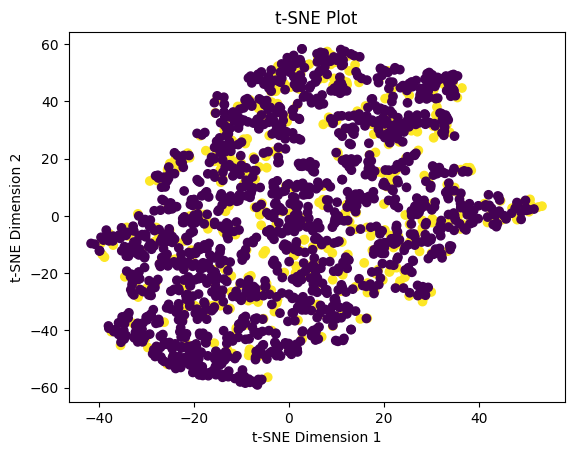

In [10]:
import matplotlib.pyplot as plt
# Plot t-SNE
plt.scatter(df_imp['coor_x'], df_imp['coor_y'], c= df_imp['Replication'])
plt.title('t-SNE Plot')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [110]:
l_cat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]

# update column
df_imp['PATNR'] = df_z['PATNR'].astype(str).copy()
df_imp['Replication'] = df_imp['Replication'].astype(float)

#df_imp['Age_Early'] = df_imp['Age_Early'].fillna(0)
##df_imp['Age_Late'] =df_imp['Age_Late'].fillna(0)
df_imp = df_imp.fillna(0)

l_cat_spec = ['RF']
l_cat_spec.extend(l_cat_patnr)
l_cat_spec = l_cat_spec[:-3]
l_cat_spec.append('patnr')
l_cat_spec.append('Replication')
l_cat_spec.pop(-5)


# Save embedding + projection
df_z.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/BeSt_embedding_projections_withCRP.csv', index=False, sep=',')

# Important to start with RF -> (why i do not knwo)

func.visualize_umap_bokeh_na_2(X_embedded, df_imp[l_cat_spec],  l_cat_spec, l_binary=l_cat_spec, patient_id='patnr', cluster_id='RF', title='MMAE_UMAP2',  path='/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/BeSt_MMAE_withCRP.html')

1821 1821
0 []

UMAP figure saved under location: TSNE/Baseline_MMAE_UMAP2.html


## #3 Classify novel instances (POODLE)

### #3.1 Initialize variables for patient assignment

In [111]:
from sklearn.metrics.pairwise import cosine_similarity

df_cluster = metadata_RA[['pseudoId','PhenoGraph_clusters']].copy()

# Construct patient similarity matrix from original set
sim_matrix = cosine_similarity(df_z[['LF0', 'LF1', 'LF2', 'LF3', 'LF4', 'LF5', 'LF6', 'LF7']].iloc[:1387].astype(np.float32))

# Specify columns for each modality (need to be present in both original & replication space)
d_input = {'cat' : list(df_categoric_replication[lcat].columns), 'num' : list(df_numeric_replication[lnum].columns)}

# Intialize list to save location of newly projected patients
z_new = []

# Define cluster
CLUSTER_LABEL = 'PhenoGraph_clusters'

# Initialize dataframe where we collect all predictors of interest for assigning patients to a cluster 
archetype_columns = ['weight_pval', 'weight_mean', 'weight_sd', 'cluster_mean_pat', 'cluster_sd_pat'] # + latent factors?
l_col = ['pseudoId', CLUSTER_LABEL]
for i in range(len(np.unique(df_cluster[CLUSTER_LABEL]))):
    l_col.extend(['%s_%s' % (col, i) for col in archetype_columns ])

df_characteristics = pd.DataFrame(columns=l_col)

### #3.2 Project the patients onto latent space and see how they are oriented

In [112]:
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
import importlib as imp
import numpy 
imp.reload(pup)
np.seterr('raise') # reveal potential floating point errors

# Bookmark identifier (use fake)
df_id = pd.DataFrame({'pseudoId' : ['id_' + str(i) for i in range(len(df_numeric_replication))]})

for ix, new_pat in enumerate(df_id['pseudoId']):
    # collect sample information
    new_pat = str(df_id.iloc[ix]['pseudoId'])
    sample_cat = df_categoric_replication[lcat].iloc[ix]
    sample_num = df_numeric_replication[lnum].iloc[ix]
    #sample =  sample_cat.append(sample_num)
    sample = pd.concat([sample_cat, sample_num], axis=0)
    sample.name = new_pat

    # create metadata
    df_meta = pup.getMetaDataPatient(df_cluster, list(df_cluster['pseudoId'].values), new_pat)
    
    l_orientation = [df_id.iloc[ix]['pseudoId'], -1]
    
    # What is the orientation of the patient compared to each cluster
    # In other words, which cluster has the largest gravity on the patient
    l_orientation.extend(pup.getOrientation(model, df_meta, pd.DataFrame(df_z[['LF0', 'LF1', 'LF2', 'LF3', 'LF4', 'LF5', 'LF6', 'LF7']].iloc[:1387]), d_input, sample, sim_matrix=sim_matrix, cluster_label='PhenoGraph_clusters'))

    # Bookmark cluster characteristics
    df_characteristics.loc[len(df_characteristics)] = l_orientation
    
df_characteristics['pseudoId'] = df_id['pseudoId'].copy()
df_characteristics.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/ClusterCharacteristics_Projection_BeSt_withCRP.csv', index=False, sep=',')
df_characteristics.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,-1,0.000001,0.906205,0.068047,0.814774,0.073542,0.000001,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.787643,0.067935,0.000001,0.796162,0.143558,0.718439,0.120183
1,id_1,-1,0.000001,0.906205,0.068047,0.880069,0.062519,0.000001,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.877626,0.052651,1.000000,0.796162,0.143558,0.833011,0.096519
2,id_2,-1,0.000001,0.906205,0.068047,0.880069,0.063197,0.000626,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.922243,0.051150,0.000189,0.796162,0.143558,0.771293,0.112441
3,id_3,-1,0.000001,0.906205,0.068047,0.566097,0.121991,0.000001,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.629667,0.093811,0.000001,0.796162,0.143558,0.639425,0.188360
4,id_4,-1,0.000001,0.906205,0.068047,0.753411,0.099998,0.000001,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.763697,0.075849,0.112120,0.796162,0.143558,0.785301,0.145445


### #3.3 Build Poodle classifier

#### #3.3.1 Quantify orientation of original samples with respect to clusters

In [ ]:
import pandas as pd
import numpy as np
from math import exp
from scipy.stats import ttest_ind
from scipy.spatial.distance import cosine# cosine minkowski
from sklearn.metrics.pairwise import cosine_similarity
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
#import importlib as imp
#imp.reload(pup)
CLUSTER_LABEL = 'PhenoGraph_clusters'
# Initialize similarity matrix
# We only need to calculate the pairwise similarities of the initial space 1 time
#sim_matrix = cosine_similarity(z_filtered.astype(np.float32))

df_characteristics_original = pup.quantifySimilarity(df_cluster, sim_matrix, CLUSTER_LABEL = 'PhenoGraph_clusters')
    
# Bookmark cluster characteristics
df_characteristics_original['pseudoId'] = df_cluster['pseudoId'].copy()
df_characteristics_original[CLUSTER_LABEL] = df_cluster[CLUSTER_LABEL].copy()
df_characteristics_original.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/ClusterCharacteristics_Original_withCRP.csv', index=False, sep=',')
df_characteristics_original.head()

#### #3.3.2 Optimize weights with simple classifier

TRAIN: [222 223 224 225 226 227 228 229 230 231] TEST: [0 1 2 3 4 5 6 7 8 9]
[09:16:30] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [222 223 224 225 226 227 228 229 230 231]
[09:16:30] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [444 445 446 447 448 449 450 451 452 453]
[09:16:30] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [666 667 668 669 670 671 672 673 674 675]
[09:16:30] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [888 889 890 891 892 893 894 895 896 897]
[09:16:30] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.



Text(0.5, 1.0, 'Confusion matrix for the Poodle labeler (XGB) on trainingsset (ACC: 1.00)')

<Figure size 640x480 with 0 Axes>

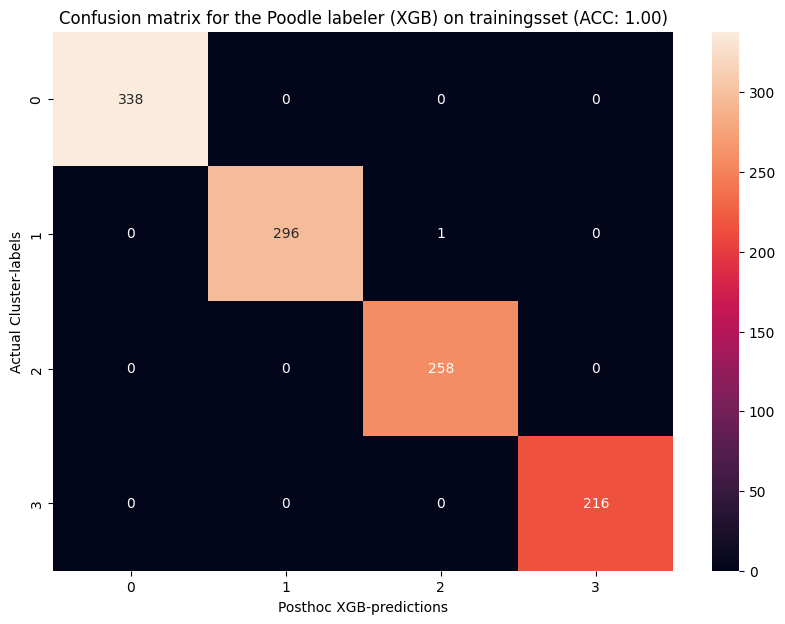

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import xgboost as xgb
import matplotlib.pyplot as plt
import time
import seaborn as sn
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np

df_train, df_test = train_test_split(df_characteristics_original, test_size=0.2,  random_state=28072022) # stratify=df_characteristics['PhenoGraph_clusters'],

target = 'PhenoGraph_clusters'

cols_data = [x for x in list(df_train.columns) if x not in ['pseudoId', target]] #   'Sex', 'Age', 

X = df_train[cols_data].values
y = df_train[target]

# Apply 5 fold CV
kf = KFold(n_splits=5) # 
iteration = 0
y_pred = []
y_proba = []

for train_index, test_index in kf.split(X):
    print("TRAIN:", train_index[:10], "TEST:", test_index[:10])
    X_train, X_test = pd.DataFrame(X).loc[train_index], pd.DataFrame(X).loc[test_index]
    y_train, y_test = np.take(y, np.array(train_index)),np.take(y, np.array(test_index))#.values  # .values

    # Z-score scaling
    scaler = StandardScaler().fit(X_train)
    X_train= scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # Model is an XGBClassifier
    n_trees = 50
    dmat_train = xgb.DMatrix(X_train, y_train)
    dmat_test = xgb.DMatrix(X_test, y_test)
    
    t0 = time.time()
    xgb_clf = xgb.XGBClassifier(objective='multi:softmax', eval_metric='auc', num_class=len(y.unique()), n_trees=50)
    xgb_clf = xgb_clf.fit(X_train, y_train)

    
    t1 = time.time()
    #print('Time for Training XGB model %s: %s' % (str(iteration+1), str(t1-t0)))
    iteration += 1
    
    # Create a confusion matrix over all data!
    #y_pred.extend(bst.predict(dmat_test))
    y_proba.extend(xgb_clf.predict_proba(X_test))
    y_pred.extend(xgb_clf.predict(X_test))
    
fig = plt.figure()
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)


df_cm = pd.DataFrame(cm, index = list(range(len(y.unique()))),
                  columns = list(range(len(y.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Poodle labeler (XGB) on trainingsset (ACC: %.2f)' % (accuracy))

#### #3.3.3 Show performance on hold-out test set

Text(0.5, 1.0, 'Confusion matrix for the Poodle labeler (XGB) in independent test set (ACC: 1.00)')

<Figure size 640x480 with 0 Axes>

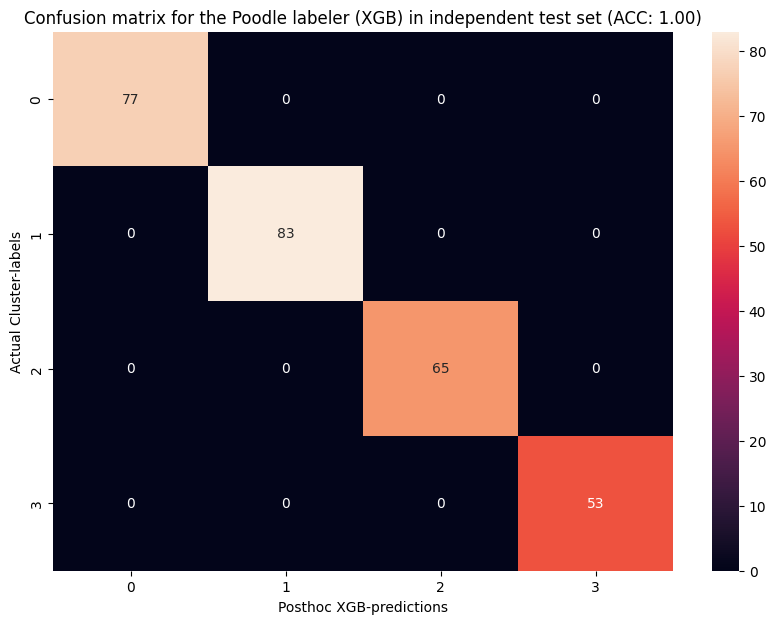

In [116]:
X_test_final = df_test[cols_data].values
y_test_final = df_test[target]

# Z-score scaling
#scaler = StandardScaler().fit(X_test)
X_test_final = scaler.transform(X_test_final)
y_pred_final = xgb_clf.predict(X_test_final)


fig = plt.figure()
cm = confusion_matrix(y_test_final, y_pred_final)
accuracy = accuracy_score(y_test_final, y_pred_final)


df_cm = pd.DataFrame(cm, index = list(range(len(y_test_final.unique()))),
                  columns = list(range(len(y_test_final.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Poodle labeler (XGB) in independent test set (ACC: %.2f)' % (accuracy))

#### #3.3.4 Compare to dummy classifier

Text(0.5, 1.0, 'Confusion matrix for the Dummy labeler (XGB) in independent test set (ACC: 0.50)')

<Figure size 640x480 with 0 Axes>

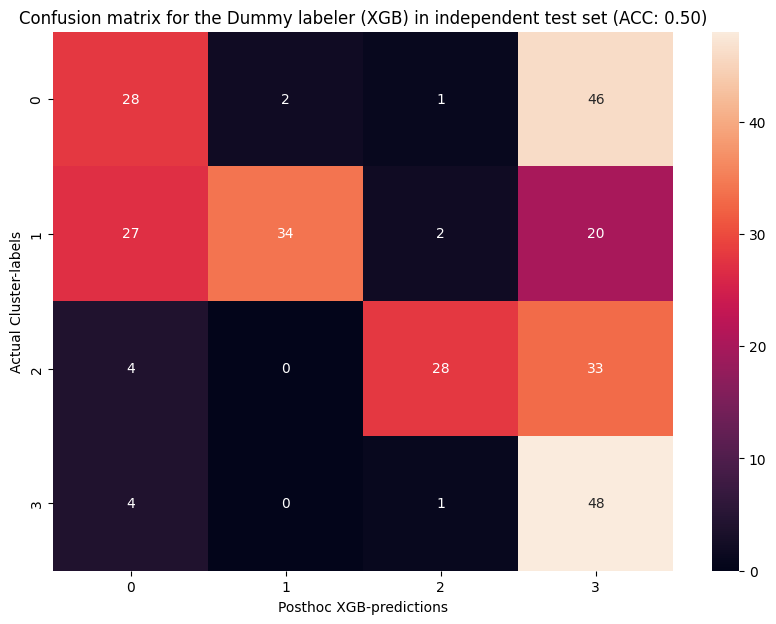

In [117]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score

def dummyLabeler(X):
    return np.argmax(X) # largest p

target = 'PhenoGraph_clusters'

X = df_test[[col for col in df_test.columns if 'weight_pval' in col]].copy()
y = df_test[target]

y_pred = []

for ix in range(len(X)): # loop through patients
    y_pred.append(dummyLabeler(X.iloc[ix]))

fig = plt.figure()
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

df_cm = pd.DataFrame(cm, index = list(range(len(y.unique()))),
                  columns = list(range(len(y.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Dummy labeler (XGB) in independent test set (ACC: %.2f)' % (accuracy))

#### #3.3.5 Train final model on all labeled data & Save model

In [310]:
from sklearn.model_selection import KFold
import xgboost as xgb
import matplotlib.pyplot as plt

import time
import seaborn as sn
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from pickle import dump

CLUSTER_LABEL = 'PhenoGraph_clusters'

X_all = df_characteristics_original[cols_data]
y_all = df_characteristics_original[CLUSTER_LABEL]

scaler = StandardScaler().fit(X_all)

X_all = scaler.transform(X_all)

dmat_train = xgb.DMatrix(X_all, y_all)

t0 = time.time()
n_trees=365 #378 #378 #365  # 352 = 13% # 57 = 13%
#'eval_metric':'mlogloss', 'learning_rate': .1, 'max_features':'gini', 'max_depth':8, 'grow_policy':'depthwise', 'num_class':len(y.unique())
bst  = xgb.train({'objective': 'multi:softmax',  'booster': 'gbtree', 'eval_metric':'mlogloss', 'learning_rate': .1, 'max_features':'gini', 'max_depth':8, 'grow_policy':'lossguide', 'num_class':len(y.unique())}, dmat_train, # 'num_class':len(y.unique())
                    n_trees, evals=[(dmat_train, "train")]) # "tree_method": "gpu_hist", 'gamma': 8, , (dmat_test, "test")
t1 = time.time()

# save poodle labeler
bst.save_model("../../models/BeSt_poodle_withCRP/xgb_model.json")

# save scaler
dump(scaler, open('../../models/BeSt_poodle_withCRP/scaler.pkl', 'wb'))


[09:55:12] WARNING: ../src/learner.cc:767: 
Parameters: { "max_features" } are not used.

[0]	train-mlogloss:1.19547
[1]	train-mlogloss:1.04209
[2]	train-mlogloss:0.91514
[3]	train-mlogloss:0.80801
[4]	train-mlogloss:0.71634
[5]	train-mlogloss:0.63711
[6]	train-mlogloss:0.56811
[7]	train-mlogloss:0.50766
[8]	train-mlogloss:0.45443
[9]	train-mlogloss:0.40739
[10]	train-mlogloss:0.36569
[11]	train-mlogloss:0.32861
[12]	train-mlogloss:0.29558
[13]	train-mlogloss:0.26609
[14]	train-mlogloss:0.23973
[15]	train-mlogloss:0.21612
[16]	train-mlogloss:0.19496
[17]	train-mlogloss:0.17597
[18]	train-mlogloss:0.15891
[19]	train-mlogloss:0.14358
[20]	train-mlogloss:0.12978
[21]	train-mlogloss:0.11736
[22]	train-mlogloss:0.10618
[23]	train-mlogloss:0.09610
[24]	train-mlogloss:0.08701
[25]	train-mlogloss:0.07881
[26]	train-mlogloss:0.07141
[27]	train-mlogloss:0.06474
[28]	train-mlogloss:0.05871
[29]	train-mlogloss:0.05326
[30]	train-mlogloss:0.04835
[31]	train-mlogloss:0.04390
[32]	train-mlogloss:0.03

[284]	train-mlogloss:0.00168
[285]	train-mlogloss:0.00168
[286]	train-mlogloss:0.00167
[287]	train-mlogloss:0.00167
[288]	train-mlogloss:0.00167
[289]	train-mlogloss:0.00167
[290]	train-mlogloss:0.00167
[291]	train-mlogloss:0.00167
[292]	train-mlogloss:0.00167
[293]	train-mlogloss:0.00167
[294]	train-mlogloss:0.00167
[295]	train-mlogloss:0.00167
[296]	train-mlogloss:0.00167
[297]	train-mlogloss:0.00167
[298]	train-mlogloss:0.00167
[299]	train-mlogloss:0.00167
[300]	train-mlogloss:0.00167
[301]	train-mlogloss:0.00167
[302]	train-mlogloss:0.00167
[303]	train-mlogloss:0.00167
[304]	train-mlogloss:0.00167
[305]	train-mlogloss:0.00167
[306]	train-mlogloss:0.00167
[307]	train-mlogloss:0.00167
[308]	train-mlogloss:0.00166
[309]	train-mlogloss:0.00166
[310]	train-mlogloss:0.00166
[311]	train-mlogloss:0.00166
[312]	train-mlogloss:0.00166
[313]	train-mlogloss:0.00166
[314]	train-mlogloss:0.00166
[315]	train-mlogloss:0.00166
[316]	train-mlogloss:0.00166
[317]	train-mlogloss:0.00166
[318]	train-ml

### #3.4 Use POODLE to cluster new instances

In [311]:
import sys
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
sys.path.append(r'../')
from poodle import utils as pup
import pandas as pd
from pickle import load

df_new = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/ClusterCharacteristics_Projection_BeSt_withCRP.csv', sep=',')

# Define input columns
target = 'PhenoGraph_clusters'
cols_data = [x for x in list(df_new.columns) if x not in ['pseudoId', target]]

# Classify patients
X_replication = df_new[cols_data]#.

# load the scaler
#scaler = load(open('../../models/BeSt_poodle_overTime/scaler.pkl', 'rb'))
scaler = load(open('../../models/BeSt_poodle_withCRP/scaler.pkl', 'rb')) #_withCRP
#X_replication = scaler.transform(X_replication)

df_new['PhenoGraph_clusters'] = pup.classifyPatient(X_replication, path="../../models/BeSt_poodle_withCRP/")  # _withCRP
df_new.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/ClusterAssignment_BeSt_withCRP.csv', index=False, sep=',')
df_new.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,2.0,0.000001,0.906205,0.068047,0.814774,0.073542,0.000001,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.787643,0.067935,0.000001,0.796162,0.143558,0.718439,0.120183
1,id_1,0.0,0.000001,0.906205,0.068047,0.880069,0.062519,0.000001,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.877626,0.052651,1.000000,0.796162,0.143558,0.833011,0.096519
2,id_2,1.0,0.000001,0.906205,0.068047,0.880069,0.063197,0.000626,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.922243,0.051150,0.000189,0.796162,0.143558,0.771293,0.112441
3,id_3,3.0,0.000001,0.906205,0.068047,0.566097,0.121991,0.000001,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.629667,0.093811,0.000001,0.796162,0.143558,0.639425,0.188360
4,id_4,3.0,0.000001,0.906205,0.068047,0.753411,0.099998,0.000001,0.95416,0.035782,...,0.000001,0.939211,0.049465,0.763697,0.075849,0.112120,0.796162,0.143558,0.785301,0.145445


## Visualize difference in clusters

In [ ]:
import pandas as pd

df_new = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/ClusterAssignment_BeSt_withCRP.csv', sep=',')

# import metadata of SyG replication set
metadata_rep = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/metadata_best_withCRP.csv', sep='|')
metadata_rep = metadata_rep[metadata_rep['PATNR'].isin(l_pat_repl)].copy()
metadata_rep = metadata_rep.reset_index(drop=True)

metadata_rep['Replication'] = 1
# add cluster info for projected patietns
metadata_rep['PhenoGraph_clusters'] = df_new['PhenoGraph_clusters'].copy() # len(metadata['PhenoGraph_clusters'].unique())+1


## Compare to metadata with ESR instead of CRP

In [ ]:
import pandas as pd
#import plotly.graph_objects as go
import numpy as np

metadata_total = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/BeST_Complete_META.csv', sep=';')

df_cluster_Original = metadata_total[metadata_total['Replication']==1]
#
# Original clustering information (same samples as development set)
df_cluster_Original[df_cluster_Original['PATNR'].isin(metadata_rep['PATNR'])].reset_index(drop=True)

# Compare old vs new clustering
d_cluster = dict(zip(metadata_rep['PATNR'], metadata_rep['PhenoGraph_clusters']))
df_cluster_Original['Cluster_NEW'] = df_cluster_Original['PATNR'].apply(lambda x: d_cluster[x] if x in d_cluster.keys() else np.nan)
df_cluster_Original = df_cluster_Original.dropna(subset=['Cluster_NEW'])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create the confusion matrix
df = df_cluster_Original[['Cluster_NEW', 'PhenoGraph_clusters']].reset_index(drop=True).copy()
df.columns = ['Clusters with ESR', 'Clusters with CRP']
confusion_matrix = pd.crosstab(df['Clusters with ESR'], df['Clusters with CRP'], rownames=['Clusters with ESR'], colnames=['Clusters with CRP'])
#print(confusion_matrix)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [322]:
from sklearn.metrics import accuracy_score, adjusted_rand_score, normalized_mutual_info_score

# Accuracy
accuracy = accuracy_score(df['Clusters with CRP'], df['Clusters with ESR'])
print(f"Accuracy: {accuracy}")

# Adjusted Rand Index (ARI)
ari = adjusted_rand_score(df['Clusters with CRP'], df['Clusters with ESR'])
print(f"Adjusted Rand Index: {ari}")

# Normalized Mutual Information (NMI)
nmi = normalized_mutual_info_score(df['Clusters with CRP'], df['Clusters with ESR'])
print(f"Normalized Mutual Information: {nmi}")

Accuracy: 0.8709677419354839
Adjusted Rand Index: 0.691836017319737
Normalized Mutual Information: 0.6296564680342437


<Figure size 640x480 with 0 Axes>

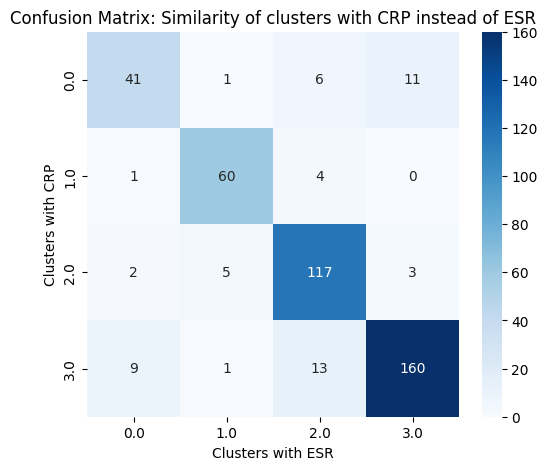

            sens   spec    ppv    npv  accuracy
0.0        0.695  0.968  0.774  0.953     0.931
1.0        0.923  0.981  0.896  0.986     0.972
2.0        0.921  0.925  0.836  0.966     0.924
3.0        0.874  0.944  0.920  0.912     0.915
macro-avg  0.853  0.955  0.856  0.954     0.871


In [331]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, accuracy_score

def class_wise_report(y_true, y_pred, class_names=None, digits=3):
    """
    Return a DataFrame with sensitivity, specificity, ppv, npv, accuracy
    for every class in a multiclass problem plus a final 'macro-average' row.
    """
    labels = np.unique(y_true)
    if class_names is None:
        class_names = [f"class_{i}" for i in labels]

    mcm = multilabel_confusion_matrix(y_true, y_pred, labels=labels)

    metrics = []
    for i, label in enumerate(labels):
        tn, fp, fn, tp = mcm[i].ravel()
        sens = tp / (tp + fn + 1e-9)
        spec = tn / (tn + fp + 1e-9)
        ppv  = tp / (tp + fp + 1e-9)
        npv  = tn / (tn + fn + 1e-9)
        acc  = (tp + tn) / (tp + tn + fp + fn)
        metrics.append([sens, spec, ppv, npv, acc])

    # macro-average
    macro = np.array(metrics).mean(axis=0)
    metrics.append(macro)

    # overall (micro) accuracy
    overall_acc = accuracy_score(y_true, y_pred)

    # build DataFrame
    class_names = list(class_names)
    class_names.append("macro-avg")
    df = pd.DataFrame(metrics,
                      columns=["sens", "spec", "ppv", "npv", "accuracy"],
                      index=class_names)
    df.loc["macro-avg", "accuracy"] = overall_acc   # overwrite with micro accuracy
    return df.round(digits)


fig = plt.figure()

# 1️⃣ Compute confusion matrix
cm = confusion_matrix(df['Clusters with CRP'], df['Clusters with ESR'])
labels = np.unique(df['Clusters with CRP'])

# 2️⃣ Using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Clusters with ESR')
plt.ylabel('Clusters with CRP')
plt.title('Confusion Matrix: Similarity of clusters with CRP instead of ESR')
plt.show()

# Accuracy
accuracy = np.trace(cm) / np.sum(cm)
print(class_wise_report(df['Clusters with CRP'], df['Clusters with ESR'],
                            class_names=labels))

#print("Accuracy:", accuracy)

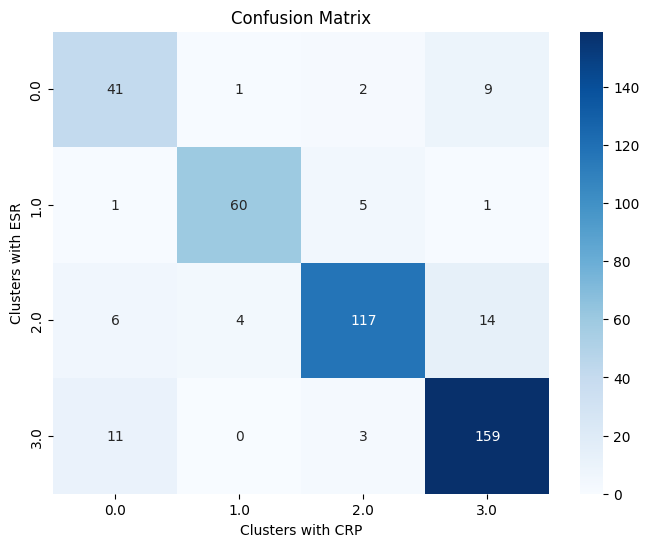

In [297]:
import matplotlib.pyplot as plt # 'lambda': 0.000005, 
import seaborn as sns
# Create the confusion matrix
df = df_cluster_Original[['Cluster_NEW', 'PhenoGraph_clusters']].reset_index(drop=True).copy()
df.columns = ['Clusters with ESR', 'Clusters with CRP']
confusion_matrix = pd.crosstab(df['Clusters with ESR'], df['Clusters with CRP'], rownames=['Clusters with ESR'], colnames=['Clusters with CRP'])
#print(confusion_matrix)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()